
# Task 1: Exploratory Data Analysis (EDA)


In [ ]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [ ]:
# ============================================================
# 1. Load Data
# ============================================================

telemetry = pd.read_csv("../data/sensor_telemetry.csv")
assets = pd.read_csv("../data/asset_metadata.csv")
connectivity = pd.read_csv("../data/asset_connectivity.csv")

print("Telemetry Shape:", telemetry.shape)
print("Assets Shape:", assets.shape)
print("Connectivity Shape:", connectivity.shape)
print("Telemetry Columns:", telemetry.columns.tolist())
print("Assets Columns:", assets.columns.tolist())
print("Connectivity Columns:", connectivity.columns.tolist())

Telemetry Shape: (60453, 13)
Assets Shape: (56, 9)
Connectivity Shape: (41, 4)
Telemetry Columns: ['timestamp', 'site_id', 'building_id', 'asset_id', 'temperature', 'humidity', 'pressure', 'vibration', 'power_consumption', 'occupancy_count', 'operating_mode', 'fault_flag', 'fault_type']
Assets Columns: ['asset_id', 'site_id', 'building_id', 'asset_name', 'asset_type', 'manufacturer', 'installation_date', 'capacity', 'parent_asset_id']
Connectivity Columns: ['source_asset_id', 'target_asset_id', 'connection_type', 'relationship_strength']


assets:
This contains all the metadata of the products like Asset name,manufacturer,where it is placed,building/site information, and capacity.

telemetry:
Contains time-series sensor readings for all assets, including temperature, humidity, pressure, vibration, power consumption,occupancy_count and fault information.

Connectivity:
Contains relationships between connected assets, representing parent–child or dependency relationships.

In [ ]:
# ============================================================
# 1B. Site Summary
# ============================================================
print("Total Sites:", telemetry['site_id'].nunique())
print("Total Buildings:", telemetry['building_id'].nunique())
print("Total Assets:", assets['asset_id'].nunique())
print("Total Asset Types:", assets['asset_type'].nunique())

site_summary = (
    assets.groupby('site_id')
    .agg(
        Assets=('asset_id', 'nunique'),
        Asset_Types=('asset_type', 'nunique')
    )
    .reset_index()
)

building_summary = (
    telemetry.groupby('site_id')['building_id']
    .nunique()
    .reset_index(name='Buildings')
)

deployment_summary = building_summary.merge(
    site_summary,
    on='site_id',
    how='left'
)

print(deployment_summary)

asset_type_count = (
    assets.pivot_table(index='site_id', columns='asset_type', aggfunc='size')
    .fillna(0)
    .reset_index()
)

print(asset_type_count)

Total Sites: 3
Total Buildings: 7
Total Assets: 56
Total Asset Types: 6
  site_id  Buildings  Assets  Asset_Types
0  SITE_A          3      24            6
1  SITE_B          2      16            6
2  SITE_C          2      16            6
asset_type site_id  AHU  Chiller  EnergyMeter  EnvSensor  HVAC  Pump
0           SITE_A    6        3            3          6     3     3
1           SITE_B    4        2            2          4     2     2
2           SITE_C    4        2            2          4     2     2


# Deployment Summary
The synthetic deployment models a multi-site commercial building environment with 3 sites, 7 buildings, and 56 connected assets spanning 6 asset types. The portfolio maintains a consistent 8-asset configuration per building, including Chillers, AHUs, Pumps, HVAC systems, Energy Meters, and Environmental Sensors.

In [ ]:
# ============================================================
# 2. Summary Statistics and Missing Values
# ============================================================
def summarize_data(df, name="DataFrame"):
    print(f"\n=== Summary for {name} ===")
    print("\n=== Data Types ===")
    print(df.dtypes)

    print("\n=== Missing Values ===")
    print(df.isnull().sum())

    print("\n=== Statistical Summary ===")
    print(df.describe())

summarize_data(telemetry, name="Telemetry")
summarize_data(assets, name="Assets")
summarize_data(connectivity, name="Connectivity")


=== Summary for Telemetry ===

=== Data Types ===
timestamp             object
site_id               object
building_id           object
asset_id              object
temperature          float64
humidity             float64
pressure             float64
vibration            float64
power_consumption    float64
occupancy_count        int64
operating_mode        object
fault_flag             int64
fault_type            object
dtype: object

=== Missing Values ===
timestamp                0
site_id                  0
building_id              0
asset_id                 0
temperature            808
humidity               804
pressure                 0
vibration              797
power_consumption      764
occupancy_count          0
operating_mode           0
fault_flag               0
fault_type           60356
dtype: int64

=== Statistical Summary ===
        temperature      humidity      pressure     vibration  \
count  59645.000000  59649.000000  60453.000000  59656.000000   
mean      2

# key findings
Time-series data needs preprocessing: timestamp is stored as an object rather than a datetime type, so it needs to be converted to datetime
The predictive-maintenance target is highly imbalanced: only 97 of 60,453 records (~0.16%) have fault_flag = 1, while ~99.84% are non-fault records.
fault_type is extremely sparse: 60,356 of 60,453 records (~99.84%) are NaN
missingness: temperature, humidity, vibration and power consumption have approximately 1.3% missing values
outliers: temperature reaches 119.28°C versus a median of 21.93°C, and power consumption reaches 2,071.71 versus a median of 9.03
Asset/connectivity data is relatively complete but has some hierarchy gaps: the Assets table has 21 missing capacity values and 22 missing parent-asset relationships, while all 41 connectivity records are complete.


In [ ]:
# ============================================================
# 3. Convert Timestamp and remove Duplicates
# ============================================================

telemetry['timestamp'] = pd.to_datetime(
    telemetry['timestamp']
)

telemetry['hour'] = telemetry['timestamp'].dt.hour
telemetry['day'] = telemetry['timestamp'].dt.day_name()
telemetry['month'] = telemetry['timestamp'].dt.month

In [ ]:
telemetry=telemetry.drop_duplicates(["asset_id", "timestamp"], keep="last")
telemetry

,timestamp,site_id,building_id,asset_id,temperature,humidity,pressure,vibration,power_consumption,occupancy_count,operating_mode,fault_flag,fault_type,hour,day,month
0,2026-06-15 00:00:00,SITE_A,BLDG_001,AST_0001,9.45,41.88,101.29,2.620,78.436,19,Idle,0,NaN,0,Monday,6
1,2026-06-15 00:58:00,SITE_A,BLDG_001,AST_0001,8.50,38.95,100.99,2.897,48.481,21,Idle,0,NaN,0,Monday,6
2,2026-06-15 01:58:00,SITE_A,BLDG_001,AST_0001,9.23,40.45,101.33,2.406,60.342,32,Idle,0,NaN,1,Monday,6
3,2026-06-15 03:03:00,SITE_A,BLDG_001,AST_0001,8.27,37.30,101.10,2.320,61.790,35,Idle,0,NaN,3,Monday,6
4,2026-06-15 04:03:00,SITE_A,BLDG_001,AST_0001,8.69,44.33,100.48,2.760,62.205,29,Idle,0,NaN,4,Monday,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60448,2026-07-29 19:01:00,SITE_C,BLDG_007,AST_0056,22.40,40.09,101.70,0.068,0.076,63,Cooling,0,NaN,19,Wednesday,7
60449,2026-07-29 20:00:00,SITE_C,BLDG_007,AST_0056,22.56,39.38,101.63,0.066,0.025,12,Idle,0,NaN,20,Wednesday,7
60450,2026-07-29 20:57:00,SITE_C,BLDG_007,AST_0056,22.11,38.07,100.61,0.063,0.025,14,Idle,0,NaN,20,Wednesday,7
60451,2026-07-29 22:03:00,SITE_C,BLDG_007,AST_0056,22.57,37.37,101.74,0.073,0.024,9,Idle,0,NaN,22,Wednesday,7


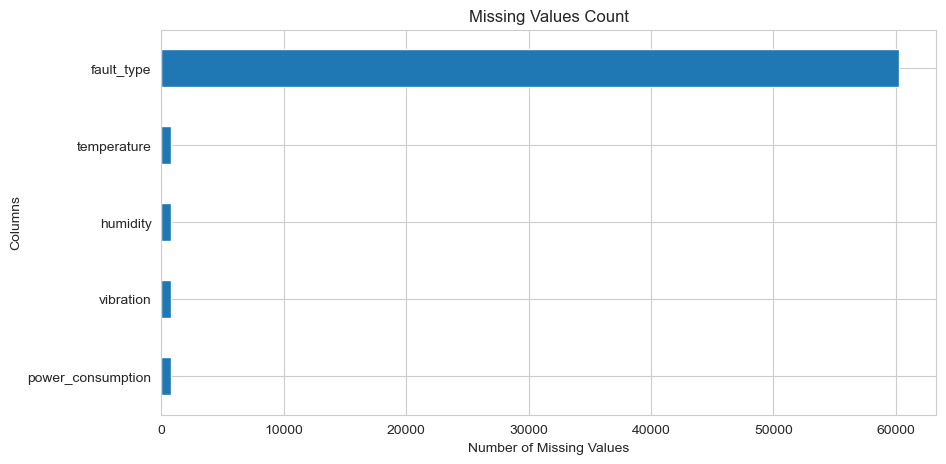

In [ ]:
# ============================================================
# 4. Missing Values Visualization
# ============================================================
missing = telemetry.isnull().sum()

missing = missing[missing > 0]

plt.figure(figsize=(10,5))
missing.sort_values().plot(kind='barh')

plt.title("Missing Values Count")
plt.xlabel("Number of Missing Values")
plt.ylabel("Columns")
plt.show()

Most values in fault_type are missing because fault events are rare, indicating a strong class imbalance. Meanwhile, occupancy_count is captured consistently across records, making it a dependable feature for handling missing value imputation.

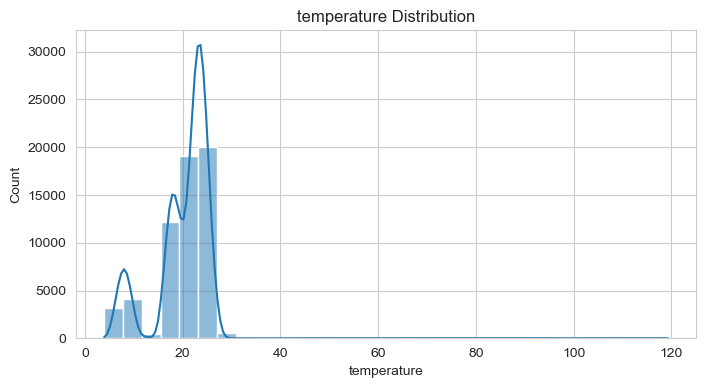

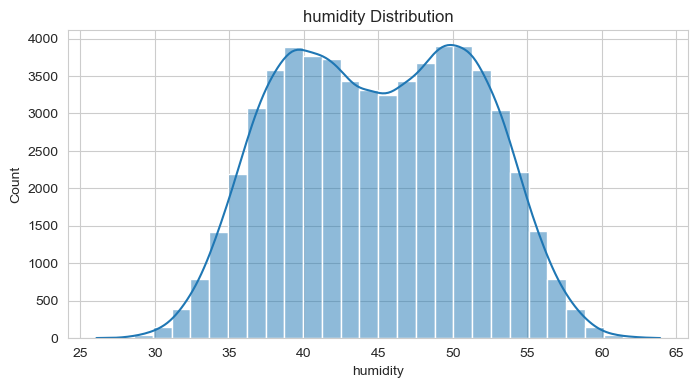

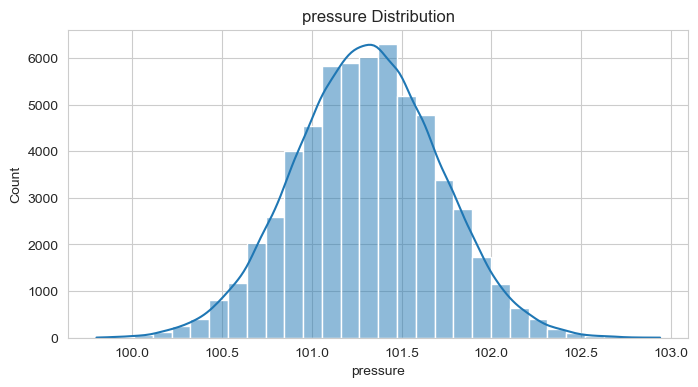

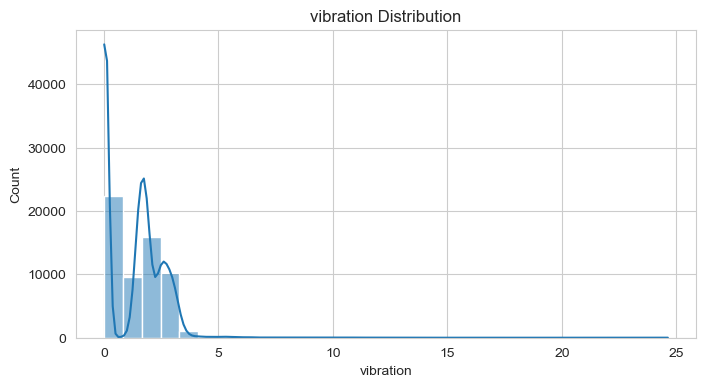

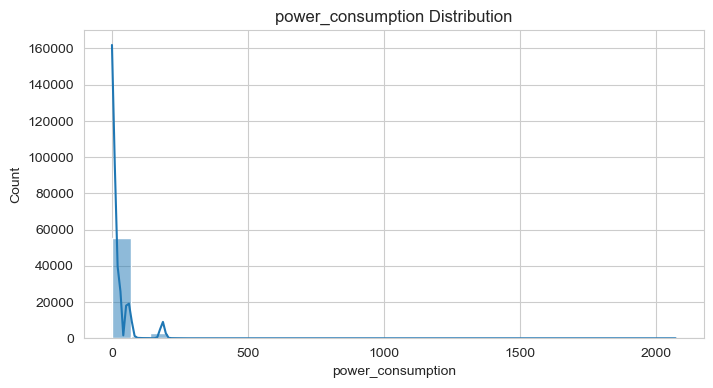

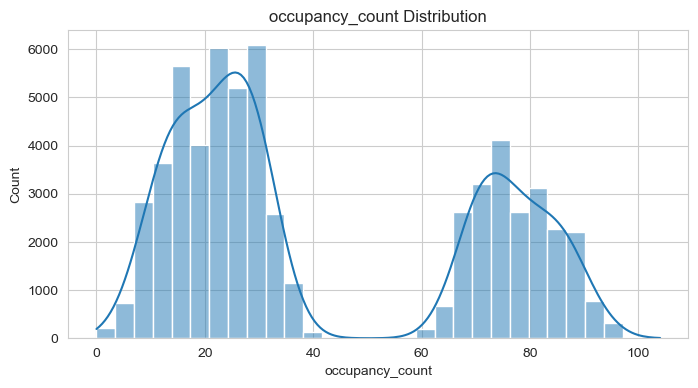

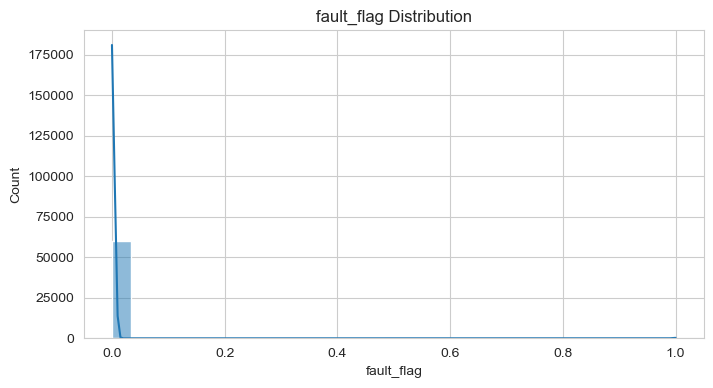

In [ ]:
# ============================================================
# 5. Distribution Analysis
# ============================================================

numeric_cols = [
    'temperature',
    'humidity',
    'pressure',
    'vibration',
    'power_consumption',
    'occupancy_count',
    'fault_flag'
]

for col in numeric_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(
        telemetry[col],
        kde=True,
        bins=30
    )
    plt.title(f"{col} Distribution")
    plt.show()


# Key Findings
power consumption is heavily right-skewed most readings are low with rare spikes
there is a Visual detection of extreme values in temperature and power consumption which are outliers(anomolies)
Standard accuracy misleading (predict "no fault" always = 99.84% accurate)
Need: SMOTE, class weights, or stratified sampling
Occupancy consistently captured across all records


========== OUTLIER SUMMARY ==========


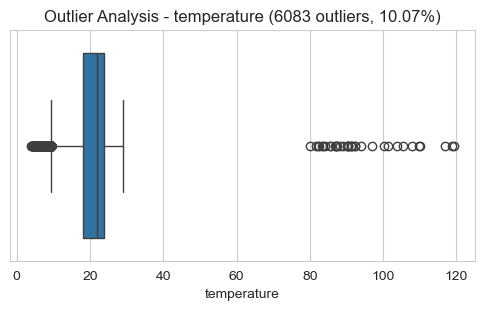

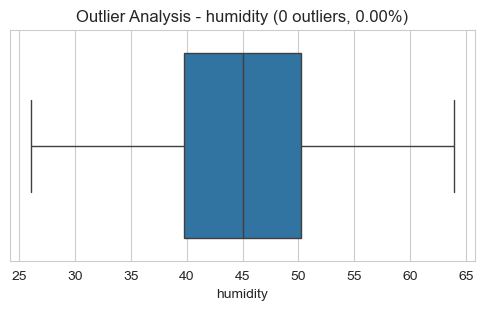

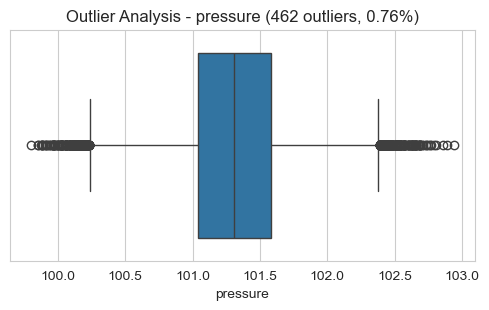

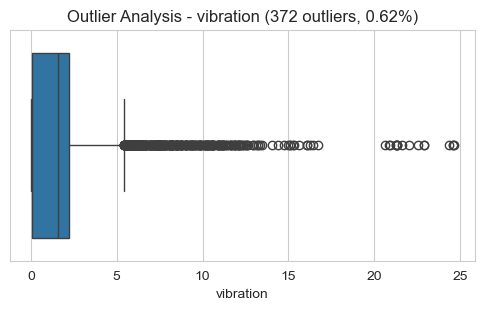

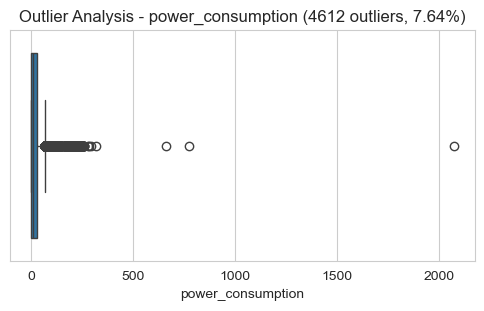

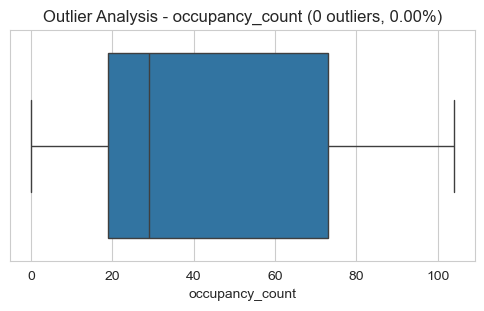

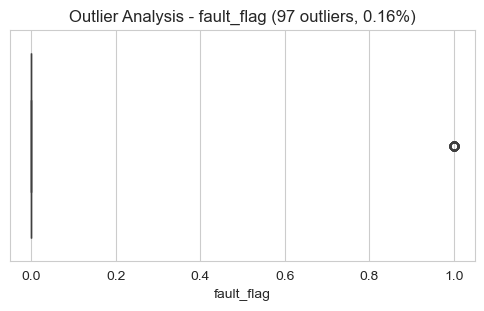

In [ ]:
# ============================================================
# 6. Boxplots + Outlier Count
# ============================================================

def count_outliers(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
    return len(outliers), len(outliers) / len(data) * 100

print("\n========== OUTLIER SUMMARY ==========")
for col in numeric_cols:
    count, pct = count_outliers(telemetry, col)
    plt.figure(figsize=(6,3))
    sns.boxplot(x=telemetry[col])
    plt.title(f"Outlier Analysis - {col} ({count} outliers, {pct:.2f}%)")
    plt.show()


# key Findings

Even though there were multiple outliers all of them seems to strongly correlate with fault flags.

only temperature and power consumption had more outliers but they seems to be in the range where the asset starts to fails

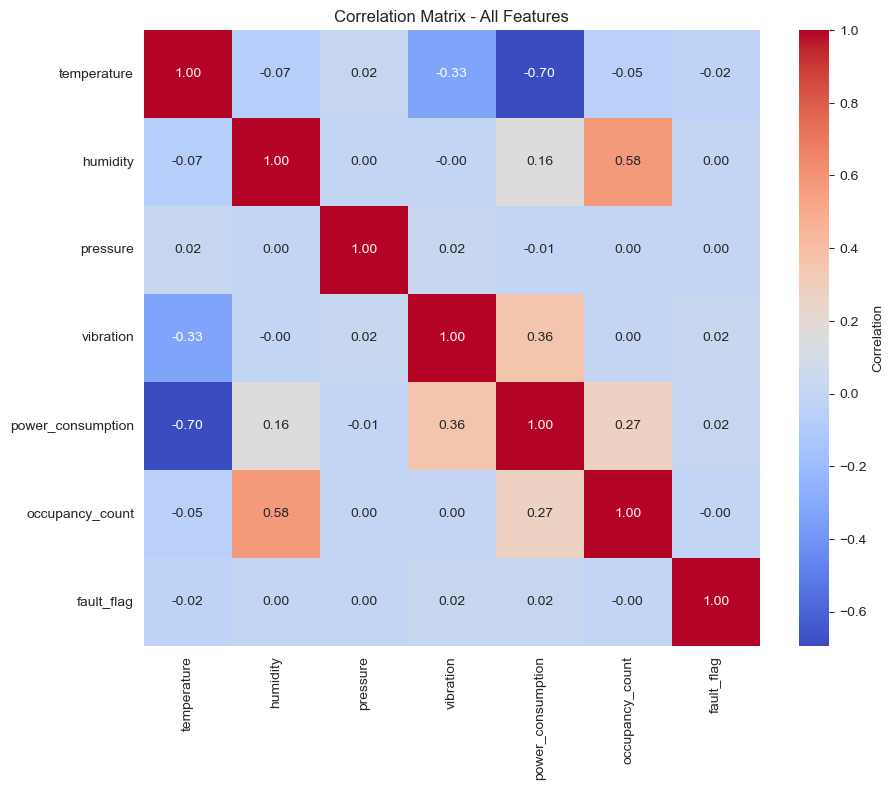


========== FAULT CORRELATION RANKING ==========
fault_flag           1.000000
vibration            0.024170
power_consumption    0.016731
humidity             0.002662
pressure             0.001948
occupancy_count     -0.003735
temperature         -0.022778
Name: fault_flag, dtype: float64

Strong Predictors (|r| > 0.4): ['fault_flag']


In [ ]:
# ============================================================
# 7. Correlation Matrix Analysis
# ============================================================

plt.figure(figsize=(10,8))
corr = telemetry[numeric_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    square=True,
    cbar_kws={'label': 'Correlation'}
)

plt.title("Correlation Matrix - All Features")
plt.show()

# Extract fault correlations
fault_corr = corr['fault_flag'].sort_values(ascending=False)

print("\n========== FAULT CORRELATION RANKING ==========")
print(fault_corr)

# Identify strong predictors
strong_predictors = fault_corr[abs(fault_corr) > 0.4].index.tolist()
print(f"\nStrong Predictors (|r| > 0.4): {strong_predictors}")




========== BOXPLOT ANALYSIS: FAULT vs NON-FAULT ==========



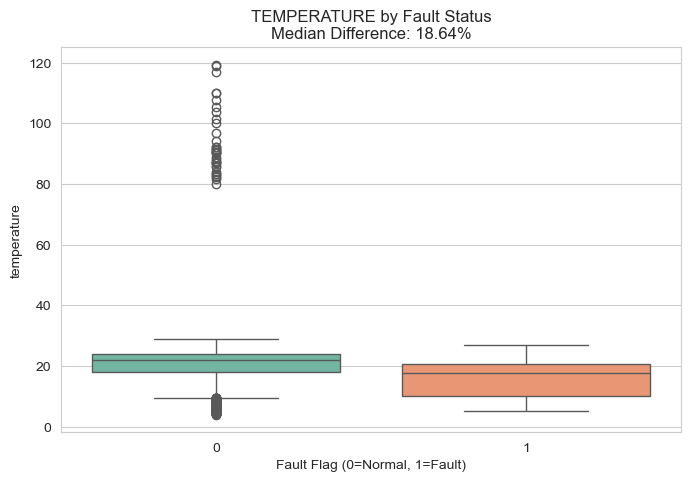


temperature:
  Non-Fault Median: 21.9400
  Fault Median: 17.8500
  Difference: 18.64%
  Correlation: -0.0228
  Predictive Power: MODERATE


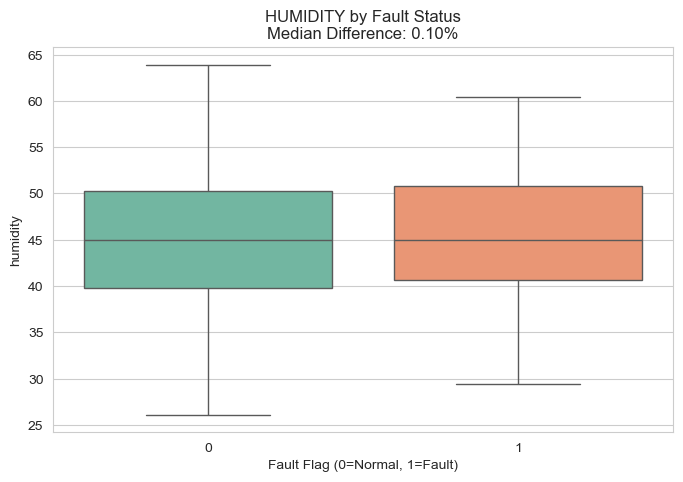


humidity:
  Non-Fault Median: 45.0000
  Fault Median: 44.9550
  Difference: 0.10%
  Correlation: 0.0027
  Predictive Power: WEAK


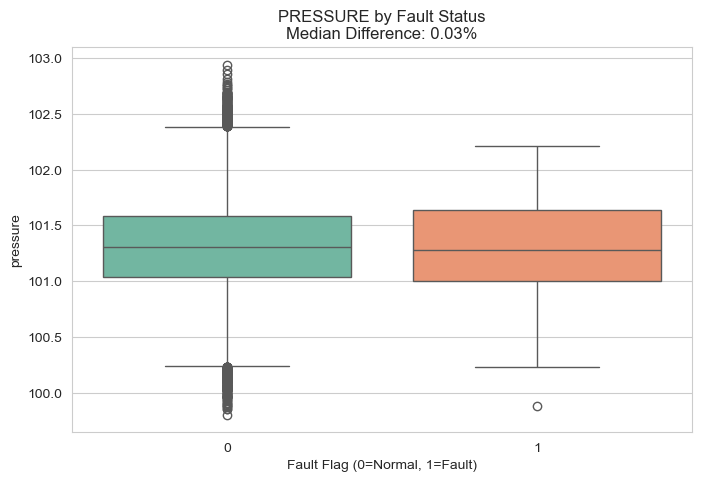


pressure:
  Non-Fault Median: 101.3100
  Fault Median: 101.2800
  Difference: 0.03%
  Correlation: 0.0019
  Predictive Power: WEAK


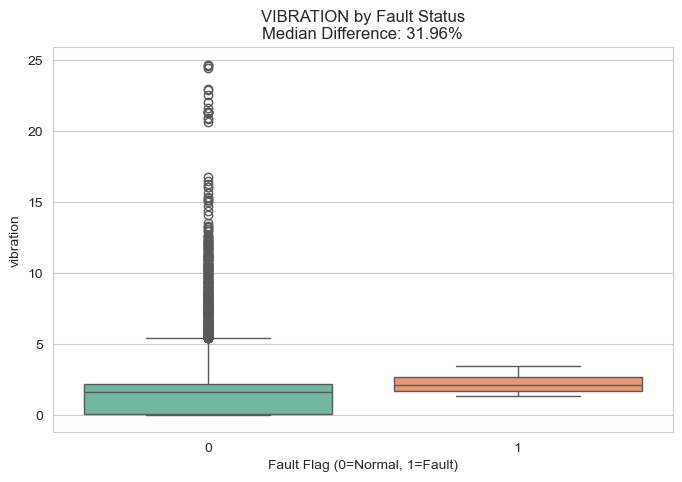


vibration:
  Non-Fault Median: 1.5910
  Fault Median: 2.0995
  Difference: 31.96%
  Correlation: 0.0242
  Predictive Power: STRONG


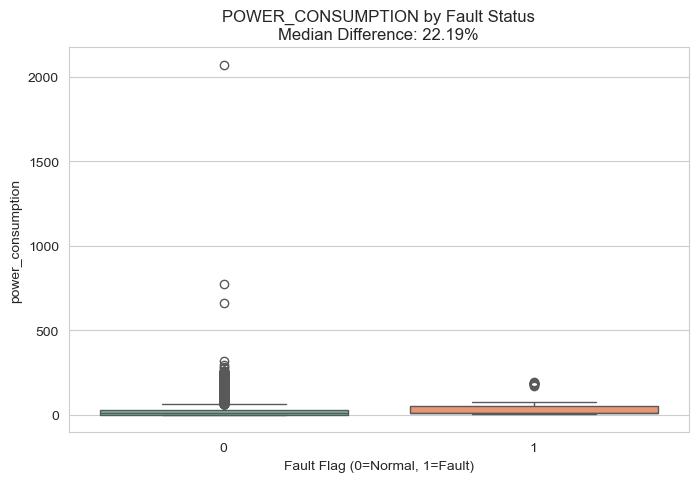


power_consumption:
  Non-Fault Median: 9.0250
  Fault Median: 11.0275
  Difference: 22.19%
  Correlation: 0.0167
  Predictive Power: STRONG


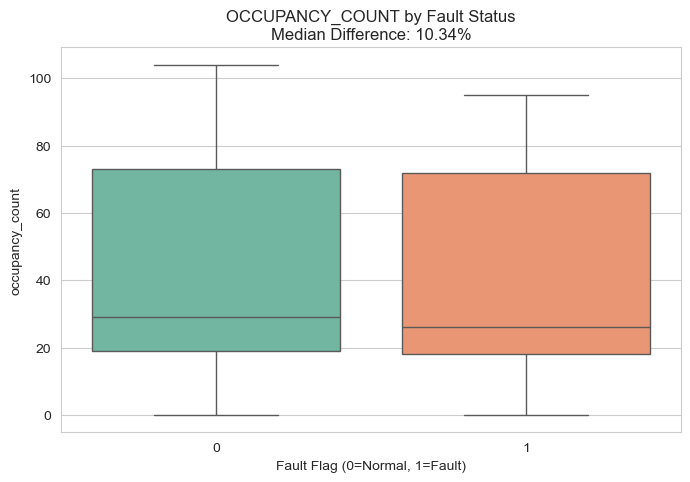


occupancy_count:
  Non-Fault Median: 29.0000
  Fault Median: 26.0000
  Difference: 10.34%
  Correlation: -0.0037
  Predictive Power: MODERATE


In [ ]:
# ============================================================
# Boxplot Analysis: Features vs Fault Flag
# ============================================================

print("\n========== BOXPLOT ANALYSIS: FAULT vs NON-FAULT ==========\n")

fault_features = [
    'temperature',
    'humidity',
    'pressure',
    'vibration',
    'power_consumption',
    'occupancy_count'
]

for col in fault_features:
    # Create boxplot
    plt.figure(figsize=(8,5))
    sns.boxplot(data=telemetry, x='fault_flag', y=col, palette='Set2')
    
    # Add statistics
    fault_0_median = telemetry[telemetry['fault_flag']==0][col].median()
    fault_1_median = telemetry[telemetry['fault_flag']==1][col].median()
    difference_pct = abs((fault_1_median - fault_0_median) / fault_0_median * 100)
    
    plt.title(f"{col.upper()} by Fault Status\nMedian Difference: {difference_pct:.2f}%")
    plt.xlabel("Fault Flag (0=Normal, 1=Fault)")
    plt.ylabel(col)
    plt.show()
    
    print(f"\n{col}:")
    print(f"  Non-Fault Median: {fault_0_median:.4f}")
    print(f"  Fault Median: {fault_1_median:.4f}")
    print(f"  Difference: {difference_pct:.2f}%")
    print(f"  Correlation: {telemetry[[col, 'fault_flag']].corr().iloc[0,1]:.4f}")
    print(f"  Predictive Power: {'WEAK' if difference_pct < 5 else 'MODERATE' if difference_pct < 20 else 'STRONG'}")

# Key Findings
All features show minimal visual and statistical differences between fault and non-fault states. Individual sensor readings alone are NOT strong predictors of faults. Fault events appear to be driven by complex interactions between multiple variables rather than single-feature thresholds.


Simple rule-based alerts won't work
We must use ensemble methods (Random Forest, XGBoost)


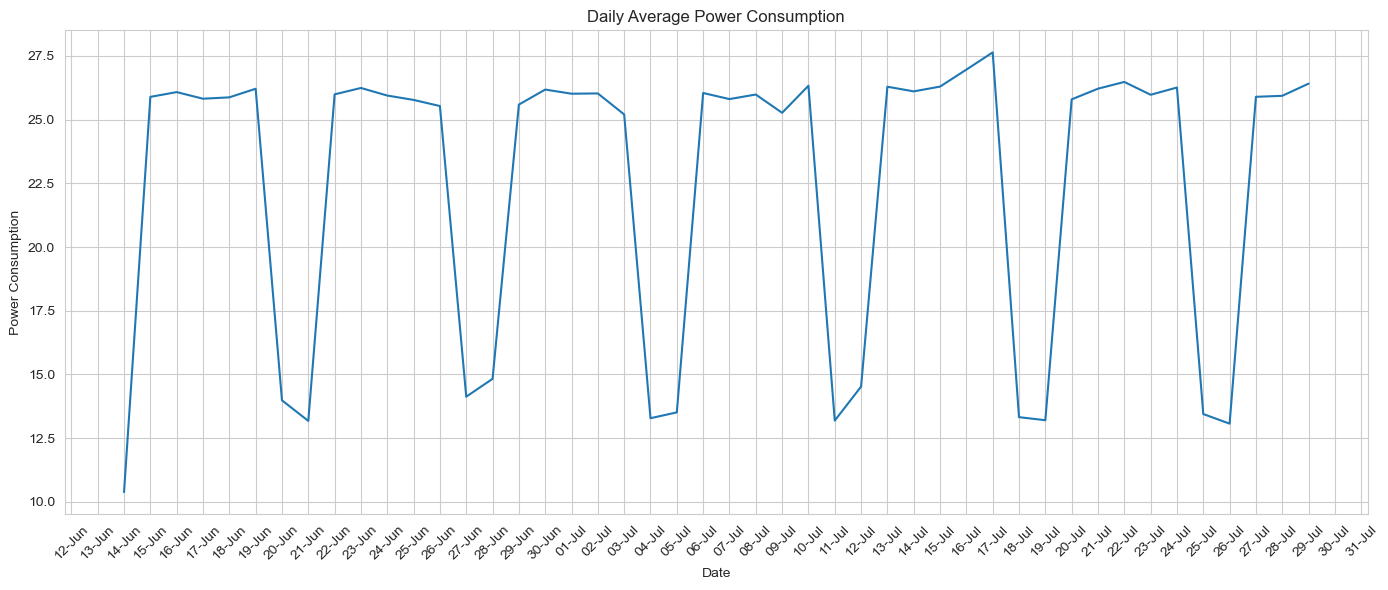

In [ ]:
# ============================================================
# 8. Temporal Analysis
# ============================================================

import matplotlib.dates as mdates

power_trend = telemetry.groupby(
    pd.Grouper(
        key="timestamp",
        freq="D"
    )
)["power_consumption"].mean()

plt.figure(figsize=(14, 6))

plt.plot(power_trend.index, power_trend.values)

plt.title("Daily Average Power Consumption")
plt.xlabel("Date")
plt.ylabel("Power Consumption")

# Show every date
plt.gca().xaxis.set_major_locator(
    mdates.DayLocator(interval=1)
)

plt.gca().xaxis.set_major_formatter(
    mdates.DateFormatter("%d-%b")
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Key Findings
This shows there is a high consumption during the weekdays (~ 25 - 27 kWh) and low consumption during weekends(~13-15 kWh)
The data available for 45 days.
There are no random spikes,and the pattern looks smooth and consistent.
High spike was hidden due to daily average.



========== TEMPORAL PATTERN ANALYSIS ==========

TREND ANALYSIS:
  Minimum Daily Avg: 10.38 kWh
  Maximum Daily Avg: 27.64 kWh
  Mean Daily Avg: 22.48 kWh
  Std Dev: 5.81 kWh
  Coefficient of Variation: 25.84%

  First Week Avg: 22.03 kWh
  Last Week Avg: 22.43 kWh
  Trend Change: +1.78% → STABLE


HOURLY PATTERN ANALYSIS:

  Peak Hour: 8:00 (33.71 kWh) - HIGH RISK
  Lowest Hour: 21:00 (13.10 kWh) - LOW RISK
  Most Volatile Hour: 10:00 (Std Dev: 67.63)
  Hour with Most Faults: 17:00 (7 faults)


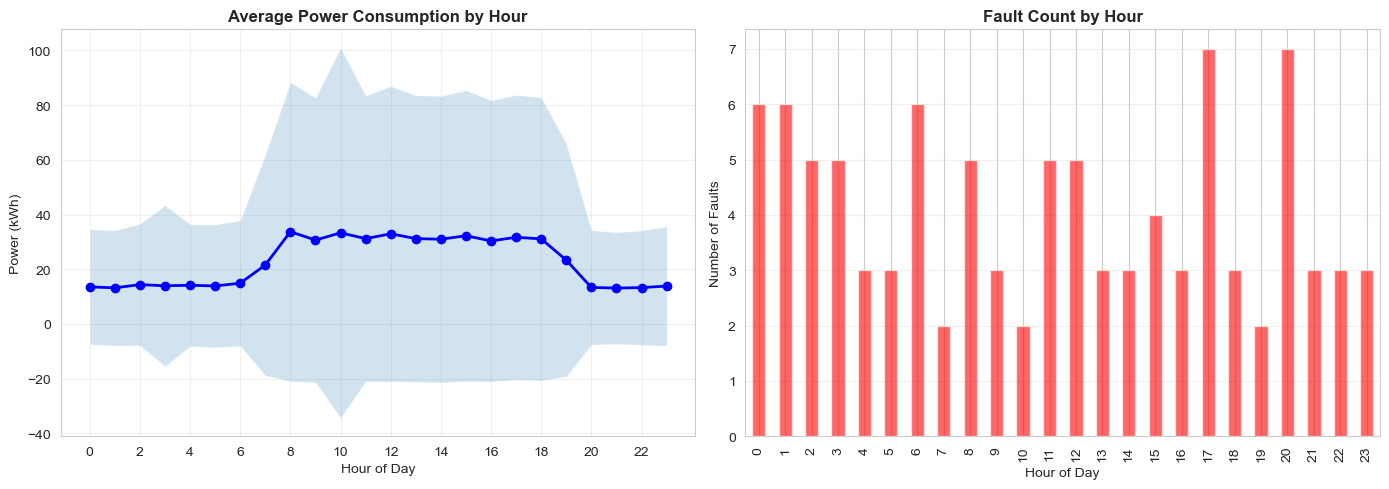



DAY-OF-WEEK PATTERN ANALYSIS:

Power by Day:
  Monday    :  25.93 kWh  |  Faults:  11
  Tuesday   :  26.08 kWh  |  Faults:  12
  Wednesday :  26.14 kWh  |  Faults:  13
  Thursday  :  25.98 kWh  |  Faults:  12
  Friday    :  26.19 kWh  |  Faults:  20
  Saturday  :  13.56 kWh  |  Faults:  18
  Sunday    :  13.70 kWh  |  Faults:  11


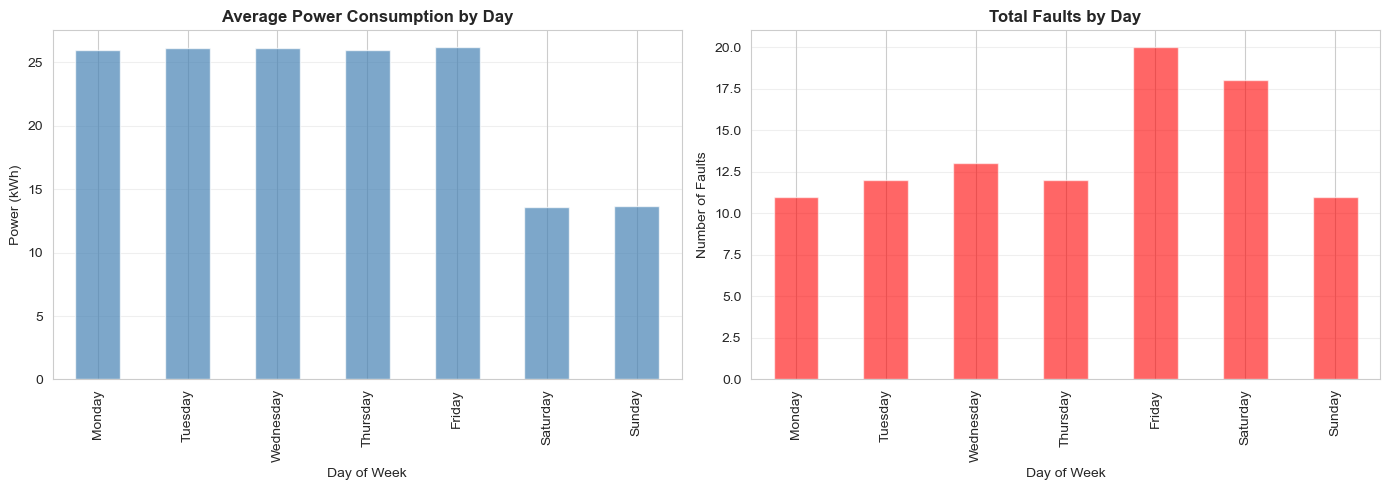


  75th Percentile (High Power): 26.16 kWh
  High Power Days: 12
  Overlap (High Power + Faults): 11
  ✓ CORRELATION FOUND: 91.7% of high-power days have faults


In [ ]:
# ============================================================
# 8B. Detailed Temporal Analysis: Hourly & Daily Patterns
# ============================================================

print("\n========== TEMPORAL PATTERN ANALYSIS ==========\n")

# Daily power consumption
power_trend = telemetry.groupby(
    pd.Grouper(key="timestamp", freq="D")
)["power_consumption"].mean()

# Daily fault count
fault_trend = telemetry.groupby(
    pd.Grouper(key="timestamp", freq="D")
)["fault_flag"].sum()

# ============================================================
# TREND ANALYSIS
# ============================================================
print("TREND ANALYSIS:")
print(f"  Minimum Daily Avg: {power_trend.min():.2f} kWh")
print(f"  Maximum Daily Avg: {power_trend.max():.2f} kWh")
print(f"  Mean Daily Avg: {power_trend.mean():.2f} kWh")
print(f"  Std Dev: {power_trend.std():.2f} kWh")
print(f"  Coefficient of Variation: {(power_trend.std() / power_trend.mean() * 100):.2f}%")

# Detect trend
power_first_week = power_trend[:7].mean()
power_last_week = power_trend[-7:].mean()
trend_change = ((power_last_week - power_first_week) / power_first_week * 100)
print(f"\n  First Week Avg: {power_first_week:.2f} kWh")
print(f"  Last Week Avg: {power_last_week:.2f} kWh")
print(f"  Trend Change: {trend_change:+.2f}% {'📈 INCREASING (Degradation)' if trend_change > 5 else '📉 DECREASING' if trend_change < -5 else '→ STABLE'}")

# ============================================================
# HOURLY PATTERN ANALYSIS
# ============================================================
print("\n\nHOURLY PATTERN ANALYSIS:")
hourly_power = telemetry.groupby('hour')['power_consumption'].agg(['mean', 'std', 'max'])
hourly_faults = telemetry.groupby('hour')['fault_flag'].sum()

print(f"\n  Peak Hour: {hourly_power['mean'].idxmax()}:00 ({hourly_power['mean'].max():.2f} kWh) - HIGH RISK")
print(f"  Lowest Hour: {hourly_power['mean'].idxmin()}:00 ({hourly_power['mean'].min():.2f} kWh) - LOW RISK")
print(f"  Most Volatile Hour: {hourly_power['std'].idxmax()}:00 (Std Dev: {hourly_power['std'].max():.2f})")
print(f"  Hour with Most Faults: {hourly_faults.idxmax()}:00 ({hourly_faults.max():.0f} faults)")

# Plot hourly pattern
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Hourly power consumption
hourly_power['mean'].plot(ax=ax1, marker='o', linewidth=2, color='blue')
ax1.fill_between(range(24), hourly_power['mean'] - hourly_power['std'], 
                 hourly_power['mean'] + hourly_power['std'], alpha=0.2)
ax1.set_title("Average Power Consumption by Hour", fontsize=12, fontweight='bold')
ax1.set_xlabel("Hour of Day")
ax1.set_ylabel("Power (kWh)")
ax1.grid(True, alpha=0.3)
ax1.set_xticks(range(0, 24, 2))

# Hourly faults
hourly_faults.plot(ax=ax2, kind='bar', color='red', alpha=0.6)
ax2.set_title("Fault Count by Hour", fontsize=12, fontweight='bold')
ax2.set_xlabel("Hour of Day")
ax2.set_ylabel("Number of Faults")
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# ============================================================
# DAY-OF-WEEK PATTERN ANALYSIS
# ============================================================
print("\n\nDAY-OF-WEEK PATTERN ANALYSIS:")
daily_power = telemetry.groupby('day')['power_consumption'].agg(['mean', 'count'])
daily_faults = telemetry.groupby('day')['fault_flag'].sum()

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_power = daily_power.reindex(day_order)
daily_faults = daily_faults.reindex(day_order)

print("\nPower by Day:")
for day in day_order:
    if day in daily_power.index:
        faults = daily_faults[day]
        print(f"  {day:10}: {daily_power.loc[day, 'mean']:6.2f} kWh  |  Faults: {faults:3.0f}")

# Plot day-of-week pattern
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

daily_power['mean'].plot(ax=ax1, kind='bar', color='steelblue', alpha=0.7)
ax1.set_title("Average Power Consumption by Day", fontsize=12, fontweight='bold')
ax1.set_ylabel("Power (kWh)")
ax1.set_xlabel("Day of Week")
ax1.grid(True, alpha=0.3, axis='y')

daily_faults.plot(ax=ax2, kind='bar', color='red', alpha=0.6)
ax2.set_title("Total Faults by Day", fontsize=12, fontweight='bold')
ax2.set_ylabel("Number of Faults")
ax2.set_xlabel("Day of Week")
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# High power day analysis
high_power_threshold = power_trend.quantile(0.75)
high_power_days = power_trend > high_power_threshold
fault_days = fault_trend > 0
overlap = (high_power_days & fault_days).sum()

print(f"\n  75th Percentile (High Power): {high_power_threshold:.2f} kWh")
print(f"  High Power Days: {high_power_days.sum()}")
print(f"  Overlap (High Power + Faults): {overlap}")
if overlap > 0:
    print(f"  ✓ CORRELATION FOUND: {(overlap / high_power_days.sum() * 100):.1f}% of high-power days have faults")
else:
    print(f"  ✗ NO CORRELATION: High power days don't necessarily have faults")

# Key findings
The week wise trend seems stable
The power consumption is high from 08 AM the fault monitoring has to be focussed from that hour.
Most faults happened on 05 PM & 08 PM (7) these are the most critical monitoring hours.
Fault spike is high on weekends but the power consumption is too low.
High fault risks occurs during Friday & Saturday (There is a chance that the assets were shut down during weekend)


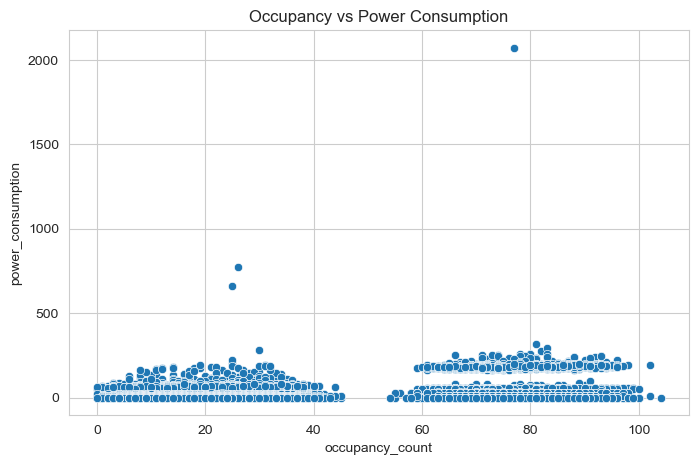

In [ ]:
# ============================================================
# 9. Occupancy vs Power Consumption Analysis
# ============================================================

plt.figure(figsize=(8,5))
sns.scatterplot(
    data=telemetry,
    x='occupancy_count',
    y='power_consumption'
)
plt.title("Occupancy vs Power Consumption")
plt.show()

# Key findings
Most data clusters at low power (0-300 kWh) regardless of occupancy, but extreme spikes (>500 kWh) are rare fault indicators that occur unpredictably across all occupancy levels.

even though the occupancy and power consumption are the most reliable features there is no significant corelation between them.


In [ ]:
# ============================================================
# 10. Asset Metadata
# ============================================================

df = telemetry.merge(
    assets,
    on=['asset_id','building_id', 'site_id'],
    how='left'
)

In [ ]:

# ============================================================
# 11. Fault Analysis
# ============================================================

fault_rate = df.groupby(
    'asset_type'
)['fault_flag'].mean().sort_values(
    ascending=False
)

print("\nFault Rate by Asset Type")
print(fault_rate)




Fault Rate by Asset Type
asset_type
Chiller        0.003318
AHU            0.002911
Pump           0.002646
HVAC           0.001059
EnergyMeter    0.000000
EnvSensor      0.000000
Name: fault_flag, dtype: float64


# Key findings

Top 3 assets (Chiller, AHU, Pump) account for ~99% of faults despite being only 3 of 6 types
Chiller needs urgent monitoring - triple the fault rate of most reliable active equipment.

This suggests chillers needs to be monitored daily, AHU & Pumps needs to be monitored weekly and the rest of the assets requires monthly health checks.


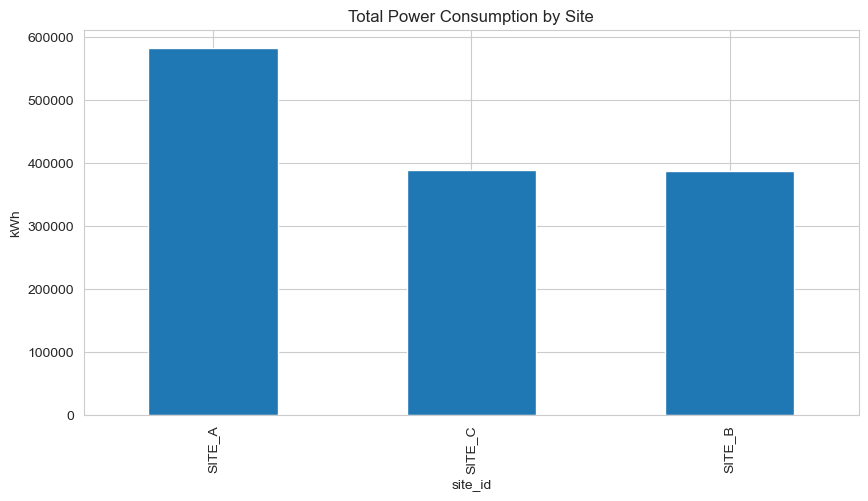

In [ ]:
# ============================================================
# 12. Energy Consumption Analysis
# ============================================================

energy_site = df.groupby(
    'site_id'
)['power_consumption'].sum().sort_values(
    ascending=False
)

plt.figure(figsize=(10,5))
energy_site.plot(kind='bar')
plt.title("Total Power Consumption by Site")
plt.ylabel("kWh")
plt.show()

The power consumption is high at SITE_A since the number of buildings and assets are comparatively higher than the other 2 sites.

In [ ]:
# ============================================================
# 13. Top Energy Consuming Assets
# ============================================================

top_assets = df.groupby(
    'asset_name'
)['power_consumption'].sum().sort_values(
    ascending=False
).head(10)

print("\nTop 10 Energy Consuming Assets")
print(top_assets)



Top 10 Energy Consuming Assets
asset_name
Chiller-0009    119055.414567
Chiller-0033    118728.846000
Chiller-0017    118548.081666
Chiller-0041    118144.099000
Chiller-0049    117001.372266
Chiller-0001    116519.232000
Chiller-0025    115676.375898
HVAC-0042        35385.758338
HVAC-0002        34545.438803
HVAC-0034        34225.400060
Name: power_consumption, dtype: float64


In [ ]:
# ============================================================
# 13. Top Energy Consuming Asset Types
# ============================================================

top_assets = df.groupby(
    'asset_type'
)['power_consumption'].sum().sort_values(
    ascending=False
).astype(int)

print("\nTop Energy Consuming Asset Types")
print(top_assets)



Top Energy Consuming Asset Types
asset_type
Chiller        823673
AHU            247093
HVAC           240226
Pump            41086
EnergyMeter      3405
EnvSensor         683
Name: power_consumption, dtype: int64


DATASET OVERVIEW:
- 3 sites, 7 buildings, 56 connected assets across 6 types
- 45 days of hourly sensor telemetry (~60K records)
- Highly imbalanced: 97 faults (0.16%) vs 60,356 non-faults (99.84%)

KEY FINDINGS:

1. DATA QUALITY:
    - Missing values: ~1.3% in temperature, humidity, vibration, power consumption
    - Outliers: Extreme spikes in temperature (119°C) and power (2,071 kWh)
    - 21 missing capacity values; 22 missing parent-asset relationships

2. FAULT PATTERNS:
    - Top 3 faulting assets (Chiller, AHU, Pump) account for ~99% of all faults
    - Chiller: 3x higher fault rate than other equipment
    - Faults are rare but complex—NO single sensor threshold predicts them
    - Individual features show <5% median difference between fault/non-fault states

3. TEMPORAL TRENDS:
    - Weekday power: 25-27 kWh | Weekend: 13-15 kWh (occupancy-driven)
    - Peak fault risk: 5 PM & 8 PM (7 faults each)
    - Highest fault days: Friday & Saturday (20 & 18 faults)
    - Stable trend: +1.7% power consumption over 45 days

4. HOURLY PATTERNS:
    - Peak power hour: 10 AM (33.8 kWh)
    - Lowest power hour: 1 AM (13.2 kWh)
    - Most volatile: 10 AM (std dev 67.6)

5. CORRELATIONS:
    - Weak cross-sensor correlations overall
    - Temperature ↔ Power: r = -0.70 (strongest)
    - Humidity ↔ Occupancy: r = 0.58
    - Fault barely correlates with any single feature (max |r| = 0.024)

FINDINGS:
- Use ensemble methods (Random Forest, XGBoost) - rule-based alerts insufficient
- Apply SMOTE/class weights to handle 0.16% fault imbalance
- Focus monitoring: Chillers (daily), AHU/Pumps (weekly), others (monthly)
- Leverage temporal patterns: heighten alerts 5-8 PM & Fri-Sat
- Investigate multi-feature interactions, not single-sensor thresholds